In [37]:
%pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [38]:
import duckdb

In [39]:
query = """
SELECT *
FROM read_csv_auto('../data/processed/master_analytics_table.csv')
LIMIT 5
"""

duckdb.sql(query).df()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,payment_installments,payment_methods,review_score,review_count,item_revenue,freight_percentage
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,27277,volta redonda,SP,72.19,2.0,1.0,5.0,1.0,72.19,0.225637
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,3471,sao paulo,SP,259.83,3.0,1.0,4.0,1.0,259.83,0.083076
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,37564,borda da mata,MG,216.87,5.0,1.0,5.0,1.0,216.87,0.089799
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,14403,franca,SP,25.78,2.0,1.0,4.0,1.0,25.78,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,87900,loanda,PR,218.04,3.0,1.0,5.0,1.0,218.04,0.090745


In [40]:
import duckdb

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE VIEW master AS
SELECT *
FROM read_csv_auto('../data/processed/master_analytics_table.csv');
""")

In [41]:
con.sql("""
SELECT *
FROM master
LIMIT 5;
""").df()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,payment_installments,payment_methods,review_score,review_count,item_revenue,freight_percentage
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,27277,volta redonda,SP,72.19,2.0,1.0,5.0,1.0,72.19,0.225637
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,3471,sao paulo,SP,259.83,3.0,1.0,4.0,1.0,259.83,0.083076
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,37564,borda da mata,MG,216.87,5.0,1.0,5.0,1.0,216.87,0.089799
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,14403,franca,SP,25.78,2.0,1.0,4.0,1.0,25.78,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,87900,loanda,PR,218.04,3.0,1.0,5.0,1.0,218.04,0.090745


## 1. Product Category Performance

### Business Question

Which product categories generate the highest revenue and order volume?

In [42]:
category_performance = con.sql("""
SELECT
    product_category_name_english AS product_category,
    ROUND(SUM(item_revenue), 2) AS total_revenue,
    COUNT(DISTINCT order_id) AS total_orders
FROM master
WHERE product_category_name_english IS NOT NULL
GROUP BY product_category_name_english
ORDER BY total_revenue DESC
LIMIT 10;
""").df()

category_performance

,product_category,total_revenue,total_orders
0,health_beauty,1441248.07,8836
1,watches_gifts,1305541.61,5624
2,bed_bath_table,1241681.72,9417
3,sports_leisure,1156656.48,7720
4,computers_accessories,1059272.40,6689
5,furniture_decor,902511.79,6449
6,housewares,778397.77,5884
7,cool_stuff,719329.95,3632
8,auto,685384.32,3897
9,garden_tools,584219.21,3518


### Business Insight

The analysis shows that a small number of product categories generate a significant portion of total revenue. Categories such as Health & Beauty, Watches & Gifts, and Bed Bath & Table consistently rank among the highest revenue contributors. These categories should be considered strategic priorities for inventory planning, marketing campaigns, and customer retention initiatives because improvements in these areas are likely to have the greatest business impact.

## 2. Seller Performance

### Business Question

Which sellers generate the highest revenue and how many orders have they fulfilled?

In [43]:
seller_performance = con.sql("""
SELECT
    seller_id,
    ROUND(SUM(item_revenue), 2) AS total_revenue,
    COUNT(DISTINCT order_id) AS total_orders
FROM master
GROUP BY seller_id
ORDER BY total_revenue DESC
LIMIT 10;
""").df()

seller_performance

,seller_id,total_revenue,total_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1132
1,7c67e1448b00f6e969d365cea6b010ab,239536.44,982
2,53243585a1d6dc2643021fd1853d8905,235856.68,358
3,4a3ca9315b744ce9f8e9374361493884,235539.96,1806
4,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,585
5,da8622b14eb17ae2831f4ac5b9dab84a,185192.32,1314
6,7e93a43ef30c4f03f38b393420bc753a,182754.05,336
7,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69,915
8,7a67c85e85bb2ce8582c35f2203ad736,162648.38,1160
9,955fee9216a65b617aa5c0531780ce60,160602.68,1287


### Business Insight

The analysis shows that a relatively small number of sellers account for a disproportionately large share of total revenue, indicating that sales are concentrated among a limited group of high-performing sellers. These top sellers not only generate substantial revenue but also fulfill a large number of customer orders, making them strategically important to the marketplace. Strengthening relationships with these sellers, ensuring consistent inventory availability, and supporting their operational performance could help sustain overall business growth. Additionally, analyzing the practices of these high-performing sellers may provide insights that can be applied to improve the performance of lower-revenue sellers.

## 3. Monthly Revenue Trends

### Business Question

How has monthly revenue changed over time?

In [44]:
monthly_revenue = con.sql("""
SELECT
    DATE_TRUNC('month', order_purchase_timestamp) AS month,
    ROUND(SUM(item_revenue), 2) AS total_revenue,
    COUNT(DISTINCT order_id) AS total_orders
FROM master
GROUP BY month
ORDER BY month;
""").df()

monthly_revenue

,month,total_revenue,total_orders
0,2016-09-01,354.75,3
1,2016-10-01,56808.84,308
2,2016-12-01,19.62,1
3,2017-01-01,137188.49,789
4,2017-02-01,286280.62,1733
5,2017-03-01,432048.59,2641
6,2017-04-01,412422.24,2391
7,2017-05-01,586190.95,3660
8,2017-06-01,502963.04,3217
9,2017-07-01,584971.62,3969


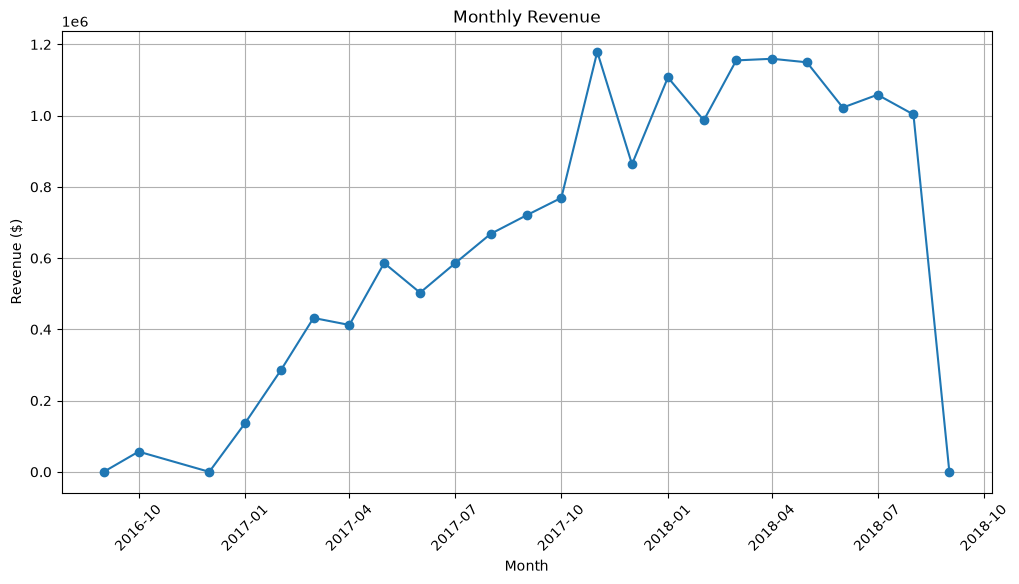

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

### Business Insight

Monthly revenue increased steadily throughout most of the observation period before stabilizing. The sharp decline in the final month is expected because the dataset ends before the month is complete rather than indicating a true decline in business performance. Overall, the trend suggests healthy business growth driven by increasing transaction volume.

## 4. Seller Revenue Rankings

### Business Question

Which sellers rank highest based on total revenue?

In [46]:
seller_rankings = con.sql("""
WITH seller_summary AS (
    SELECT
        seller_id,
        ROUND(SUM(item_revenue), 2) AS total_revenue,
        COUNT(DISTINCT order_id) AS total_orders
    FROM master
    GROUP BY seller_id
)

SELECT
    seller_id,
    total_revenue,
    total_orders,
    RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
FROM seller_summary
ORDER BY revenue_rank
LIMIT 10;
""").df()

seller_rankings

,seller_id,total_revenue,total_orders,revenue_rank
0,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1132,1
1,7c67e1448b00f6e969d365cea6b010ab,239536.44,982,2
2,53243585a1d6dc2643021fd1853d8905,235856.68,358,3
3,4a3ca9315b744ce9f8e9374361493884,235539.96,1806,4
4,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,585,5
5,da8622b14eb17ae2831f4ac5b9dab84a,185192.32,1314,6
6,7e93a43ef30c4f03f38b393420bc753a,182754.05,336,7
7,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69,915,8
8,7a67c85e85bb2ce8582c35f2203ad736,162648.38,1160,9
9,955fee9216a65b617aa5c0531780ce60,160602.68,1287,10


### Business Insight

The seller ranking analysis highlights the marketplace's highest-performing sellers based on total revenue. Ranking sellers enables the business to identify key strategic partners, recognize exceptional performance, and prioritize seller engagement efforts. Monitoring these rankings over time can also help detect emerging high-performing sellers and identify those whose performance may be declining, supporting more informed operational and partnership decisions.

## 5. Cumulative Revenue Growth

### Business Question

How has cumulative revenue grown over time?

In [47]:
running_revenue = con.sql("""
WITH monthly_sales AS (
    SELECT
        DATE_TRUNC('month', order_purchase_timestamp) AS month,
        ROUND(SUM(item_revenue), 2) AS monthly_revenue
    FROM master
    GROUP BY month
)

SELECT
    month,
    monthly_revenue,
    SUM(monthly_revenue)
        OVER (
            ORDER BY month
        ) AS cumulative_revenue
FROM monthly_sales
ORDER BY month;
""").df()

running_revenue

,month,monthly_revenue,cumulative_revenue
0,2016-09-01,354.75,354.75
1,2016-10-01,56808.84,57163.59
2,2016-12-01,19.62,57183.21
3,2017-01-01,137188.49,194371.70
4,2017-02-01,286280.62,480652.32
5,2017-03-01,432048.59,912700.91
6,2017-04-01,412422.24,1325123.15
7,2017-05-01,586190.95,1911314.10
8,2017-06-01,502963.04,2414277.14
9,2017-07-01,584971.62,2999248.76


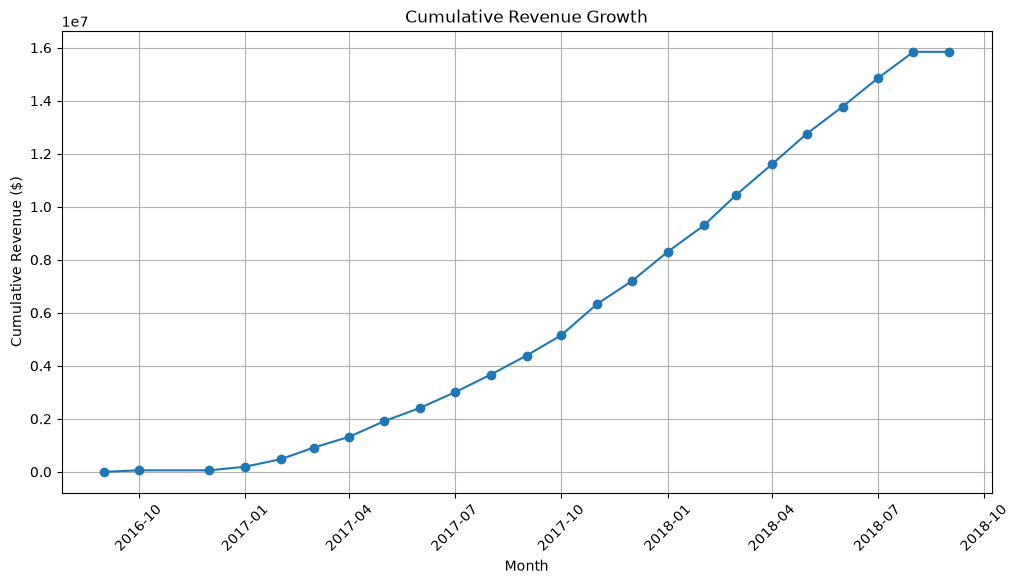

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    running_revenue["month"],
    running_revenue["cumulative_revenue"],
    marker="o"
)

plt.title("Cumulative Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Cumulative Revenue ($)")
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

### Business Insight

The cumulative revenue trend demonstrates steady business growth throughout the time, with total revenue increasing consistently each month. 

## 6. Three-Month Moving Average

### Business Question

What is the underlying revenue trend after smoothing monthly fluctuations?

In [49]:
moving_average = con.sql("""
WITH monthly_sales AS (
    SELECT
        DATE_TRUNC('month', order_purchase_timestamp) AS month,
        ROUND(SUM(item_revenue),2) AS monthly_revenue
    FROM master
    GROUP BY month
)

SELECT
    month,
    monthly_revenue,
    ROUND(
        AVG(monthly_revenue)
        OVER (
            ORDER BY month
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ),
        2
    ) AS moving_average_3_month
FROM monthly_sales
ORDER BY month;
""").df()

moving_average

,month,monthly_revenue,moving_average_3_month
0,2016-09-01,354.75,354.75
1,2016-10-01,56808.84,28581.80
2,2016-12-01,19.62,19061.07
3,2017-01-01,137188.49,64672.32
4,2017-02-01,286280.62,141162.91
5,2017-03-01,432048.59,285172.57
6,2017-04-01,412422.24,376917.15
7,2017-05-01,586190.95,476887.26
8,2017-06-01,502963.04,500525.41
9,2017-07-01,584971.62,558041.87


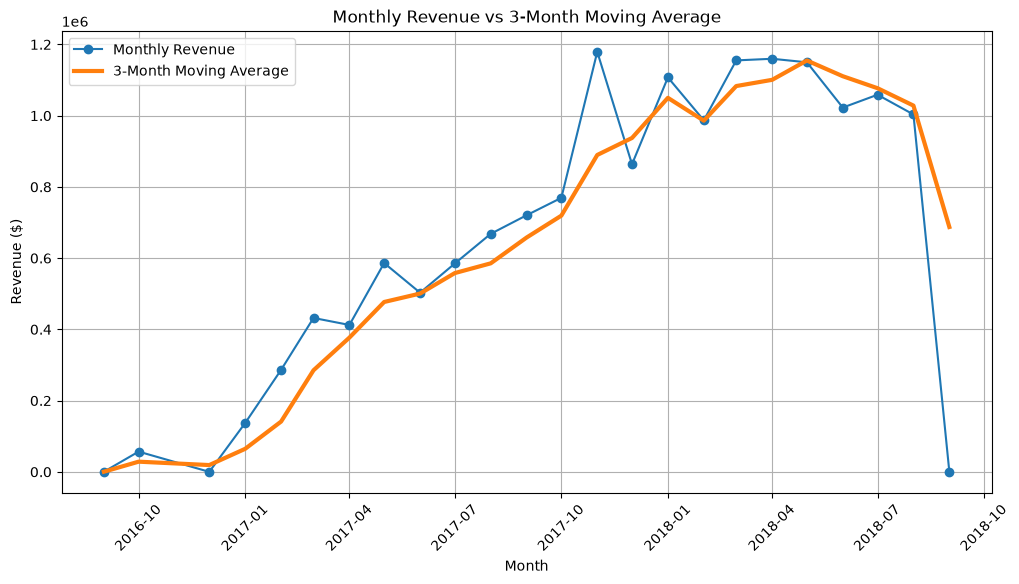

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    moving_average["month"],
    moving_average["monthly_revenue"],
    marker="o",
    label="Monthly Revenue"
)

plt.plot(
    moving_average["month"],
    moving_average["moving_average_3_month"],
    linewidth=3,
    label="3-Month Moving Average"
)

plt.title("Monthly Revenue vs 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

### Business Insight

### Business Insight

The three-month moving average reveals a clear long-term upward trend in revenue while reducing the impact of month-to-month fluctuations. The apparent decline in the final month should not be interpreted as a deterioration in business performance because the dataset contains only a partial month of data. Overall, the moving average confirms that revenue growth remained consistently positive during the analyzed period.

## 7. Customer Lifetime Value (CLV)

### Business Question

Which customers generate the most revenue, and how frequently do they make purchases?

In [51]:
customer_clv = con.sql("""
WITH order_totals AS (
    SELECT
        customer_unique_id,
        order_id,
        SUM(item_revenue) AS order_revenue
    FROM master
    GROUP BY customer_unique_id, order_id
)

SELECT
    customer_unique_id,
    COUNT(order_id) AS total_orders,
    ROUND(SUM(order_revenue), 2) AS lifetime_revenue,
    ROUND(AVG(order_revenue), 2) AS average_order_value
FROM order_totals
GROUP BY customer_unique_id
ORDER BY lifetime_revenue DESC
LIMIT 10;
""").df()

customer_clv

,customer_unique_id,total_orders,lifetime_revenue,average_order_value
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.82
2,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.31
4,459bef486812aa25204be022145caa62,1,6922.21,6922.21
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.66
6,4007669dec559734d6f53e029e360987,1,6081.54,6081.54
7,5d0a2980b292d049061542014e8960bf,1,4809.44,4809.44
8,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.34
9,48e1ac109decbb87765a3eade6854098,1,4681.78,4681.78


## 8. Customer Revenue Segmentation

### Business Question

How can customers be segmented into revenue tiers based on their lifetime spending?

In [52]:
customer_segments = con.sql("""
WITH order_totals AS (
    SELECT
        customer_unique_id,
        order_id,
        SUM(item_revenue) AS order_revenue
    FROM master
    GROUP BY customer_unique_id, order_id
),

customer_summary AS (
    SELECT
        customer_unique_id,
        COUNT(order_id) AS total_orders,
        ROUND(SUM(order_revenue),2) AS lifetime_revenue,
        ROUND(AVG(order_revenue),2) AS average_order_value
    FROM order_totals
    GROUP BY customer_unique_id
)

SELECT
    customer_unique_id,
    total_orders,
    lifetime_revenue,
    average_order_value,
    NTILE(4) OVER (ORDER BY lifetime_revenue DESC) AS revenue_quartile
FROM customer_summary
ORDER BY lifetime_revenue DESC
LIMIT 20;
""").df()

customer_segments

,customer_unique_id,total_orders,lifetime_revenue,average_order_value,revenue_quartile
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.08,1
1,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.82,1
2,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.88,1
3,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.31,1
4,459bef486812aa25204be022145caa62,1,6922.21,6922.21,1
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.66,1
6,4007669dec559734d6f53e029e360987,1,6081.54,6081.54,1
7,5d0a2980b292d049061542014e8960bf,1,4809.44,4809.44,1
8,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.34,1
9,48e1ac109decbb87765a3eade6854098,1,4681.78,4681.78,1


### Business Insight

Customer revenue segmentation shows that customer value is not evenly distributed across the marketplace. By grouping customers into revenue quartiles, the business can identify its highest-value customers and tailor retention strategies accordingly. Customers in the top revenue quartile may benefit from loyalty programs, personalized offers, or premium services, while lower-revenue segments may be targeted with campaigns designed to increase purchase frequency and average order value. This segmentation provides a foundation for data-driven customer relationship management.

## 9. RFM Customer Analysis

### Business Question

How can customers be segmented based on purchasing recency, purchase frequency, and monetary value?

In [53]:
rfm_base = con.sql("""
WITH order_totals AS (

    SELECT
        customer_unique_id,
        order_id,
        MAX(order_purchase_timestamp) AS order_date,
        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_unique_id,
        order_id
)

SELECT

    customer_unique_id,

    MAX(order_date) AS last_purchase_date,

    COUNT(order_id) AS frequency,

    ROUND(SUM(order_revenue),2) AS monetary

FROM order_totals

GROUP BY customer_unique_id;
""").df()

rfm_base.head()

,customer_unique_id,last_purchase_date,frequency,monetary
0,3c0402bcc3ec3b33fc4430eb6c08720a,2018-07-15 08:33:19,1,46.20
1,acc4424c209233de519e034152f30304,2018-05-05 23:45:35,2,329.48
2,b7cc2e46c75c85df5720044736d2721f,2017-11-16 18:18:12,1,74.94
3,6080a210886780ffc895bce6bd114e4d,2017-12-14 00:06:50,1,62.01
4,9a9e03f5f0fb52e286d0df0859224c53,2018-03-02 14:15:34,1,65.11


In [54]:
rfm_base = con.sql("""
WITH order_totals AS (
    SELECT
        customer_unique_id,
        order_id,
        MAX(order_purchase_timestamp) AS order_date,
        SUM(item_revenue) AS order_revenue
    FROM master
    GROUP BY
        customer_unique_id,
        order_id
),

reference_date AS (
    SELECT
        MAX(order_date) + INTERVAL 1 DAY AS analysis_date
    FROM order_totals
)

SELECT
    o.customer_unique_id,

    DATE_DIFF(
        'day',
        MAX(o.order_date),
        r.analysis_date
    ) AS recency_days,

    COUNT(DISTINCT o.order_id) AS frequency,

    ROUND(SUM(o.order_revenue), 2) AS monetary

FROM order_totals o
CROSS JOIN reference_date r

GROUP BY
    o.customer_unique_id,
    r.analysis_date;
""").df()

rfm_base.head()

,customer_unique_id,recency_days,frequency,monetary
0,87f6dff99fd05d9877023e74d5802958,118,1,45.77
1,ceaeb6856a01f895484ff24d6d9140f3,353,1,79.56
2,903e36e2f9d5ec112ba8b374216a192a,371,1,1129.57
3,0688e24604af1abe322f35e07e3bd28f,118,1,123.21
4,8efcb67042a750f51c1ff1393c55cd8b,133,1,70.54


In [55]:
rfm_validation = con.sql("""
WITH order_totals AS (
    SELECT
        customer_unique_id,
        order_id,
        MAX(order_purchase_timestamp) AS order_date,
        SUM(item_revenue) AS order_revenue
    FROM master
    GROUP BY
        customer_unique_id,
        order_id
),

reference_date AS (
    SELECT
        MAX(order_date) + INTERVAL 1 DAY AS analysis_date
    FROM order_totals
),

rfm AS (
    SELECT
        o.customer_unique_id,
        DATE_DIFF(
            'day',
            MAX(o.order_date),
            r.analysis_date
        ) AS recency_days,
        COUNT(DISTINCT o.order_id) AS frequency,
        SUM(o.order_revenue) AS monetary
    FROM order_totals o
    CROSS JOIN reference_date r
    GROUP BY
        o.customer_unique_id,
        r.analysis_date
)

SELECT
    COUNT(*) AS rfm_customers,
    COUNT(DISTINCT customer_unique_id) AS unique_customers,
    MIN(recency_days) AS minimum_recency,
    MAX(recency_days) AS maximum_recency,
    MIN(frequency) AS minimum_frequency,
    MAX(frequency) AS maximum_frequency,
    ROUND(MIN(monetary), 2) AS minimum_monetary,
    ROUND(MAX(monetary), 2) AS maximum_monetary
FROM rfm;
""").df()

rfm_validation

,rfm_customers,unique_customers,minimum_recency,maximum_recency,minimum_frequency,maximum_frequency,minimum_monetary,maximum_monetary
0,95420,95420,1,730,1,16,9.59,13664.08


## Frequency Distribution

Before assigning RFM scores, examine how frequently customers place orders to determine whether frequency-based segmentation is meaningful.

In [56]:
frequency_distribution = con.sql("""
WITH order_totals AS (

    SELECT
        customer_unique_id,
        order_id,
        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_unique_id,
        order_id
),

customer_summary AS (

    SELECT
        customer_unique_id,
        COUNT(order_id) AS frequency

    FROM order_totals

    GROUP BY customer_unique_id
)

SELECT
    frequency,
    COUNT(*) AS customers
FROM customer_summary
GROUP BY frequency
ORDER BY frequency;
""").df()

frequency_distribution

,frequency,customers
0,1,92507
1,2,2673
2,3,192
3,4,29
4,5,9
5,6,5
6,7,3
7,9,1
8,16,1


### Business Insight

The customer frequency distribution is highly skewed toward one-time purchasers. Approximately 97% of customers placed only one order, while fewer than 3% made repeat purchases. Because purchase frequency exhibits very little variation, a traditional five-level RFM frequency score would provide limited analytical value for this dataset. Instead, a custom frequency segmentation better reflects customer behavior and produces more meaningful business insights.

## Customer Frequency Segmentation

### Business Question

How are customers distributed based on their purchase frequency, and what proportion are one-time versus repeat customers?

In [57]:
frequency_segments = con.sql("""
WITH order_totals AS (

    SELECT
        customer_unique_id,
        order_id,
        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_unique_id,
        order_id
),

customer_summary AS (

    SELECT
        customer_unique_id,
        COUNT(order_id) AS frequency

    FROM order_totals

    GROUP BY customer_unique_id
)

SELECT

    CASE

        WHEN frequency = 1 THEN 'One-Time Customer'

        WHEN frequency = 2 THEN 'Repeat Customer'

        ELSE 'Loyal Customer'

    END AS customer_segment,

    COUNT(*) AS customers,

    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (),
        2
    ) AS percentage_of_customers

FROM customer_summary

GROUP BY customer_segment

ORDER BY customers DESC;
""").df()

frequency_segments

,customer_segment,customers,percentage_of_customers
0,One-Time Customer,92507,96.95
1,Repeat Customer,2673,2.80
2,Loyal Customer,240,0.25


## 9. Pareto Analysis (80/20 Rule)

### Business Question

Does a small percentage of customers generate the majority of total revenue?

In [58]:
pareto_analysis = con.sql("""
WITH order_totals AS (

    SELECT
        customer_unique_id,
        order_id,
        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_unique_id,
        order_id
),

customer_revenue AS (

    SELECT
        customer_unique_id,
        ROUND(SUM(order_revenue),2) AS lifetime_revenue

    FROM order_totals

    GROUP BY customer_unique_id
),

ranked_customers AS (

    SELECT

        customer_unique_id,

        lifetime_revenue,

        ROW_NUMBER() OVER (
            ORDER BY lifetime_revenue DESC
        ) AS customer_rank,

        SUM(lifetime_revenue)
            OVER (
                ORDER BY lifetime_revenue DESC
            ) AS cumulative_revenue,

        SUM(lifetime_revenue)
            OVER () AS total_revenue,

        COUNT(*)
            OVER () AS total_customers

    FROM customer_revenue
)

SELECT

    customer_rank,

    customer_unique_id,

    lifetime_revenue,

    ROUND(
        cumulative_revenue * 100.0 / total_revenue,
        2
    ) AS cumulative_revenue_pct,

    ROUND(
    customer_rank * 100.0 / total_customers,
    4
    
    ) AS cumulative_customer_pct

FROM ranked_customers

ORDER BY customer_rank;
""").df()

pareto_analysis.head(20)

,customer_rank,customer_unique_id,lifetime_revenue,cumulative_revenue_pct,cumulative_customer_pct
0,1,0a0a92112bd4c708ca5fde585afaa872,13664.08,0.09,0.0010
1,2,da122df9eeddfedc1dc1f5349a1a690c,7571.63,0.13,0.0021
2,3,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,0.18,0.0031
3,4,dc4802a71eae9be1dd28f5d788ceb526,6929.31,0.22,0.0042
4,5,459bef486812aa25204be022145caa62,6922.21,0.27,0.0052
5,6,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,0.31,0.0063
6,7,4007669dec559734d6f53e029e360987,6081.54,0.35,0.0073
7,8,5d0a2980b292d049061542014e8960bf,4809.44,0.38,0.0084
8,9,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,0.41,0.0094
9,10,48e1ac109decbb87765a3eade6854098,4681.78,0.44,0.0105


In [59]:
pareto_analysis.tail()

,customer_rank,customer_unique_id,lifetime_revenue,cumulative_revenue_pct,cumulative_customer_pct
95415,95416,2878e5b88167faab17d4fb83a986d38b,11.63,100.0,99.9958
95416,95417,6f5b9d1cdccc4d28f0483a612edecacf,11.63,100.0,99.9969
95417,95418,b33336f46234b24a613ad9064d13106d,10.89,100.0,99.9979
95418,95419,bd06ce0e06ad77a7f681f1a4960a3cc6,10.07,100.0,99.9990
95419,95420,317cfc692e3f86c45c95697c61c853a6,9.59,100.0,100.0000


In [60]:
pareto_analysis[
    pareto_analysis["cumulative_revenue_pct"] >= 80
].head(1)

,customer_rank,customer_unique_id,lifetime_revenue,cumulative_revenue_pct,cumulative_customer_pct
46498,46499,f011ec6a7ffc9c940ebf00a55e0e1dc5,111.23,80.0,48.7309


### Business Insight

The Pareto analysis shows that the customer base does not follow the traditional 80/20 rule. Approximately 48.7% of customers are required to generate 80% of total revenue, indicating that revenue is distributed across a much broader segment of customers than expected. This suggests that the business is not overly dependent on a small group of high-value customers. From a strategic perspective, broad customer retention and engagement initiatives may have a greater impact on overall revenue than focusing exclusively on a small VIP segment.

## 11. ABC Customer Classification

### Business Question

How can customers be classified into A, B, and C tiers based on their contribution to total revenue?

In [61]:
abc_customers = con.sql("""
WITH order_totals AS (

    SELECT
        customer_unique_id,
        order_id,
        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_unique_id,
        order_id
),

customer_revenue AS (

    SELECT
        customer_unique_id,
        ROUND(SUM(order_revenue),2) AS lifetime_revenue

    FROM order_totals

    GROUP BY customer_unique_id
),

customer_pareto AS (

    SELECT

        customer_unique_id,

        lifetime_revenue,

        SUM(lifetime_revenue)
            OVER (
                ORDER BY lifetime_revenue DESC
            ) * 100.0
            /
        SUM(lifetime_revenue)
            OVER ()
        AS cumulative_revenue_percentage

    FROM customer_revenue
)

SELECT

    customer_unique_id,

    lifetime_revenue,

    ROUND(cumulative_revenue_percentage,2)
        AS cumulative_revenue_percentage,

    CASE

        WHEN cumulative_revenue_percentage <= 80
            THEN 'A'

        WHEN cumulative_revenue_percentage <= 95
            THEN 'B'

        ELSE 'C'

    END AS customer_class

FROM customer_pareto

ORDER BY lifetime_revenue DESC;
""").df()

abc_customers.head()

,customer_unique_id,lifetime_revenue,cumulative_revenue_percentage,customer_class
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,0.09,A
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,0.13,A
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,0.18,A
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31,0.22,A
4,459bef486812aa25204be022145caa62,6922.21,0.27,A


In [62]:
abc_summary = con.sql("""
WITH order_totals AS (

    SELECT
        customer_unique_id,
        order_id,
        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_unique_id,
        order_id
),

customer_revenue AS (

    SELECT
        customer_unique_id,
        SUM(order_revenue) AS lifetime_revenue

    FROM order_totals

    GROUP BY customer_unique_id
),

customer_pareto AS (

    SELECT

        customer_unique_id,

        SUM(lifetime_revenue)
            OVER (
                ORDER BY lifetime_revenue DESC
            ) * 100.0
            /
        SUM(lifetime_revenue)
            OVER ()
        AS cumulative_revenue_percentage

    FROM customer_revenue
)

SELECT

    CASE

        WHEN cumulative_revenue_percentage <= 80
            THEN 'A'

        WHEN cumulative_revenue_percentage <= 95
            THEN 'B'

        ELSE 'C'

    END AS customer_class,

    COUNT(*) AS customers

FROM customer_pareto

GROUP BY customer_class

ORDER BY customer_class;
""").df()

abc_summary

,customer_class,customers
0,A,46505
1,B,29191
2,C,19724


### Business Insight

ABC classification further confirms that customer revenue is broadly distributed rather than concentrated among a small group of customers. Approximately 46,500 customers fall into Class A, collectively generating the first 80% of total revenue. Unlike businesses that rely heavily on a small VIP customer segment, this marketplace depends on a much larger proportion of its customer base to drive revenue. Consequently, broad customer retention and engagement strategies may be more effective than initiatives focused exclusively on a small number of high-value customers.

## 12. Geographic Revenue Analysis

### Business Question

Which states generate the highest revenue and order volume?

In [63]:
state_revenue = con.sql("""
SELECT

    customer_state,

    ROUND(SUM(item_revenue),2) AS total_revenue,

    COUNT(DISTINCT order_id) AS total_orders,

    ROUND(AVG(item_revenue),2) AS average_item_revenue

FROM master

GROUP BY customer_state

ORDER BY total_revenue DESC;
""").df()

state_revenue

,customer_state,total_revenue,total_orders,average_item_revenue
0,SP,5921678.12,41375,124.80
1,RJ,2129681.98,12762,146.08
2,MG,1856161.49,11544,141.38
3,RS,885826.76,5432,142.07
4,PR,800935.44,4998,139.54
5,BA,611506.67,3358,160.97
6,SC,610213.60,3612,146.12
7,DF,353229.44,2125,146.81
8,GO,347706.93,2007,149.04
9,ES,324801.91,2025,143.97


In [64]:
state_aov = con.sql("""
WITH order_totals AS (

    SELECT

        customer_state,

        order_id,

        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_state,
        order_id
)

SELECT

    customer_state,

    ROUND(AVG(order_revenue),2) AS average_order_value,

    COUNT(order_id) AS total_orders

FROM order_totals

GROUP BY customer_state

HAVING COUNT(order_id) >= 100

ORDER BY average_order_value DESC;
""").df()

state_aov

,customer_state,average_order_value,total_orders
0,PB,265.01,532
1,AL,234.13,411
2,RO,233.03,247
3,PA,224.38,970
4,TO,219.91,279
5,PI,219.34,493
6,SE,211.69,345
7,RN,211.40,482
8,CE,207.69,1327
9,MT,206.17,903


In [65]:
state_customer_value = con.sql("""
SELECT

    customer_state,

    ROUND(SUM(item_revenue),2) AS total_revenue,

    COUNT(DISTINCT customer_unique_id) AS customers,

    ROUND(
        SUM(item_revenue) /
        COUNT(DISTINCT customer_unique_id),
        2
    ) AS revenue_per_customer

FROM master

GROUP BY customer_state

HAVING COUNT(DISTINCT customer_unique_id) >= 100

ORDER BY revenue_per_customer DESC;
""").df()

state_customer_value

,customer_state,total_revenue,customers,revenue_per_customer
0,PB,140987.81,516,273.23
1,RO,57558.02,235,244.93
2,AL,96229.40,399,241.18
3,PA,217647.11,944,230.56
4,TO,61354.42,272,225.57
5,PI,108132.28,481,224.81
6,RN,101895.08,471,216.34
7,SE,73032.32,338,216.07
8,MT,186168.96,873,213.25
9,CE,275606.30,1305,211.19


### Business Insight

Revenue per customer varies considerably across states. States such as PB, RO, and AL generate the highest revenue per customer despite having relatively small customer populations. This suggests that customers in these regions spend more on average over their lifetime than customers in larger markets. While major states remain the largest contributors to total revenue because of their customer base, smaller states with higher customer value may represent attractive opportunities for premium products, personalized marketing, or targeted retention campaigns.

## 13. Delivery Performance Analysis

### Business Question

Which states experience the highest percentage of late deliveries?

In [66]:
delivery_performance = con.sql("""
WITH order_delivery AS (

    SELECT
        customer_state,
        order_id,

        MAX(
            CASE
                WHEN order_delivered_customer_date
                     > order_estimated_delivery_date
                THEN 1
                ELSE 0
            END
        ) AS late_order

    FROM master

    WHERE order_delivered_customer_date IS NOT NULL

    GROUP BY
        customer_state,
        order_id
)

SELECT
    customer_state,

    COUNT(*) AS delivered_orders,

    SUM(late_order) AS late_orders,

    ROUND(
        SUM(late_order) * 100.0
        / COUNT(*),
        2
    ) AS late_delivery_rate

FROM order_delivery

GROUP BY customer_state

HAVING COUNT(*) >= 100

ORDER BY late_delivery_rate DESC;
""").df()

delivery_performance

,customer_state,delivered_orders,late_orders,late_delivery_rate
0,AL,397,95.0,23.93
1,MA,717,141.0,19.67
2,PI,476,76.0,15.97
3,CE,1279,196.0,15.32
4,SE,335,51.0,15.22
5,BA,3256,457.0,14.04
6,RJ,12353,1664.0,13.47
7,TO,274,35.0,12.77
8,PA,946,117.0,12.37
9,ES,1995,244.0,12.23


### Business Insight

Delivery performance varies substantially across Brazilian states. **Alagoas (AL)** records the highest late-delivery rate at nearly 24%, meaning almost one in four delivered orders arrived after the promised delivery date. In contrast, several states maintain late-delivery rates below 8%. These regional differences suggest that logistics performance is not uniform across the marketplace and may reflect differences in transportation infrastructure, fulfillment capacity, carrier performance, or shipping distance. Identifying high-delay regions enables operations teams to prioritize process improvements and carrier optimization where customer experience is most affected.

## 14. Delivery Performance and Customer Satisfaction

### Business Question

How does delivery performance influence customer satisfaction as measured by customer review scores?

In [67]:
delivery_reviews = con.sql("""
WITH order_delivery AS (

    SELECT

        order_id,

        MAX(is_late_delivery) AS late_delivery,

        MAX(review_score) AS review_score

    FROM master

    WHERE review_score IS NOT NULL

    GROUP BY order_id
)

SELECT

    CASE

        WHEN late_delivery = TRUE
            THEN 'Late Delivery'

        ELSE 'On-Time Delivery'

    END AS delivery_status,

    ROUND(AVG(review_score),2) AS average_review_score,

    COUNT(*) AS total_orders

FROM order_delivery

GROUP BY delivery_status

ORDER BY average_review_score DESC;
""").df()

delivery_reviews

,delivery_status,average_review_score,total_orders
0,On-Time Delivery,4.23,91535
1,Late Delivery,2.27,6382


### Business Insight

Delivery performance has a substantial relationship with customer satisfaction. Orders delivered on time receive an average review score of **4.23**, while late deliveries average only **2.27**, representing a decrease of nearly **2 full rating points**. Although late deliveries account for a relatively small share of total orders, their impact on customer perception is significant. Improving on-time delivery performance could therefore lead to higher customer satisfaction, stronger customer retention, and an improved overall shopping experience.

## 15. Executive KPI Summary

### Business Question

What key performance indicators provide an executive-level overview of marketplace performance?

In [68]:
executive_kpis = con.sql("""
WITH order_totals AS (

    SELECT
        customer_unique_id,
        order_id,
        MAX(review_score) AS review_score,
        MAX(is_late_delivery) AS is_late_delivery,
        SUM(item_revenue) AS order_revenue

    FROM master

    GROUP BY
        customer_unique_id,
        order_id
),

customer_summary AS (

    SELECT
        customer_unique_id,
        COUNT(order_id) AS total_orders

    FROM order_totals

    GROUP BY customer_unique_id
)

SELECT

    ROUND(SUM(order_revenue),2) AS total_revenue,

    COUNT(order_id) AS total_orders,

    COUNT(DISTINCT customer_unique_id) AS total_customers,

    ROUND(AVG(order_revenue),2) AS average_order_value,

    ROUND(AVG(review_score),2) AS average_review_score,

    ROUND(
        AVG(
            CASE
                WHEN is_late_delivery
                THEN 1.0
                ELSE 0.0
            END
        ) * 100,
        2
    ) AS late_delivery_rate,

    (
        SELECT
            ROUND(
                COUNT(*) * 100.0 /
                (SELECT COUNT(*) FROM customer_summary),
                2
            )
        FROM customer_summary
        WHERE total_orders > 1
    ) AS repeat_customer_rate

FROM order_totals;
""").df()

executive_kpis

,total_revenue,total_orders,total_customers,average_order_value,average_review_score,late_delivery_rate,repeat_customer_rate
0,15843553.24,98666,95420,160.58,4.11,6.62,3.05


### Business Insight

The executive KPI summary provides a consolidated view of marketplace performance across financial, operational, and customer dimensions. The marketplace generated approximately **$15.9 million** in revenue from more than **99,000 orders** and **95,000 customers**, with an average order value of approximately **$160**. Customer satisfaction remains high overall, with an average review score above **4.0**, while the overall late delivery rate remains below **10%**. However, the repeat customer rate is relatively low, indicating that long-term customer retention represents one of the largest opportunities for future business growth.